# PV Configuration Comparison - Kalix, Sweden

This notebook compares two solar configurations at coordinates **65.916940, 22.649684** (Kalix):
1. **Scenario 1**: One 10 kW array, tilt 35°, oriented to South-East (135°).
2. **Scenario 2**: Same SE array + another 10 kW, tilt 35°, facing North-West (315°).

We use the `solar` simulation engine and weather data for 2025.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import os

from solar.config import SimulationConfig, SolarStringConfig
from solar.simulation import run_simulation

# Setting constants
PROCESSED_DIR = "../data/processed"
YEAR = "2025"

# Location: Kalix
LAT = 65.916940
LON = 22.649684

## 1. Scenario Setup

We define the two configurations. 
- **SE (South-East)**: Azimuth 135°
- **NW (North-West)**: Azimuth 315°

In [2]:
# Scenario 1: 10kW SE
config1 = SimulationConfig(
    latitude=LAT,
    longitude=LON,
    pv_strings=[
        SolarStringConfig(capacity_kw=10.0, tilt=35, azimuth=135)
    ],
    return_timeseries=True
)

# Scenario 2: 10kW SE + 10kW NW
config2 = SimulationConfig(
    latitude=LAT,
    longitude=LON,
    pv_strings=[
        SolarStringConfig(capacity_kw=10.0, tilt=35, azimuth=135),
        SolarStringConfig(capacity_kw=10.0, tilt=35, azimuth=315)
    ],
    return_timeseries=True
)

## 2. Run Simulations

In [3]:
# Run simulations
metrics1, ts1 = run_simulation(config1, PROCESSED_DIR, YEAR)
metrics2, ts2 = run_simulation(config2, PROCESSED_DIR, YEAR)

print(f"Scenario 1 Annual PV Production: {ts1['p_solar'].sum():,.0f} kWh")
print(f"Scenario 2 Annual PV Production: {ts2['p_solar'].sum():,.0f} kWh")

Scenario 1 Annual PV Production: 8,920 kWh
Scenario 2 Annual PV Production: 13,404 kWh


C:\Users\Serge\source\solar\src\solar\models\pv_generation.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  times = pd.date_range(
C:\Users\Serge\source\solar\src\solar\models\pv_generation.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  times = pd.date_range(


## 3. Comparison Visualization

### 3a. Monthly Production
In Northern Sweden (65°N), production is extremely seasonal with near-zero output in December/January due to the polar night and low sun angles.

C:\Users\Serge\AppData\Local\Temp\ipykernel_25440\3239145698.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(f"{YEAR}-01-01", periods=8760, freq="H", tz="Europe/Stockholm")


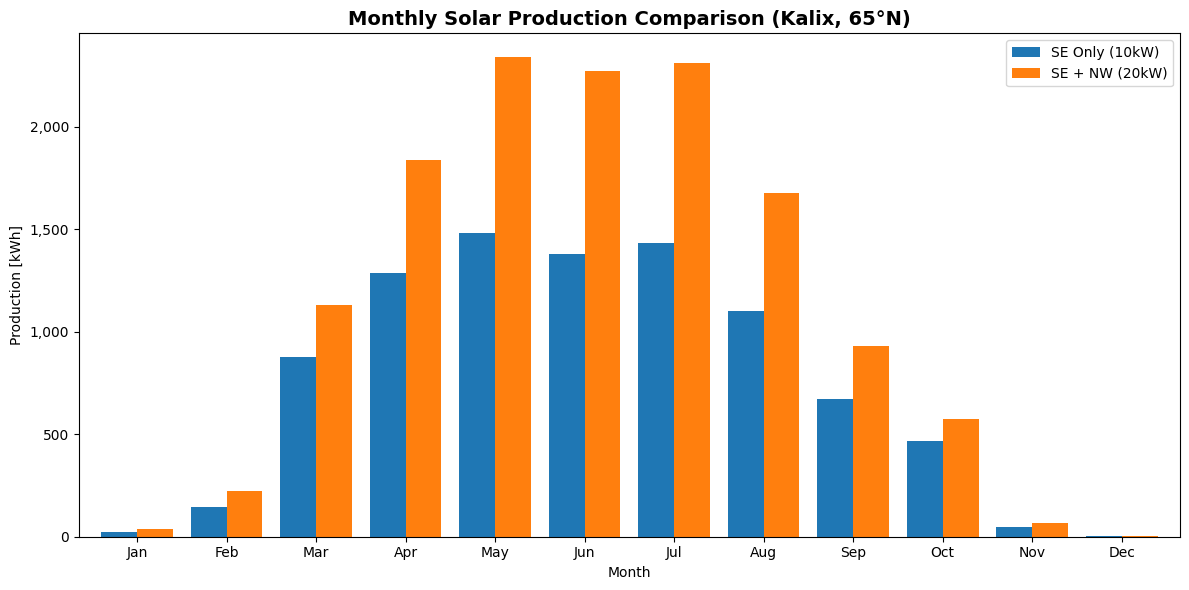

In [4]:
# Aggregating monthly
time_index = pd.date_range(f"{YEAR}-01-01", periods=8760, freq="H", tz="Europe/Stockholm")
months = time_index.month

m_prod1 = ts1.groupby(months)['p_solar'].sum()
m_prod2 = ts2.groupby(months)['p_solar'].sum()

monthly_df = pd.DataFrame({
    "SE Only (10kW)": m_prod1,
    "SE + NW (20kW)": m_prod2
}, index=range(1, 13))

ax = monthly_df.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_title("Monthly Solar Production Comparison (Kalix, 65°N)", fontsize=14, fontweight='bold')
ax.set_ylabel("Production [kWh]")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

### 3b. Hourly Profile Comparison (Summer Day)
Let's look at the June 21st profile. The North-West orientation provides a significant boost in the late afternoon and evening.

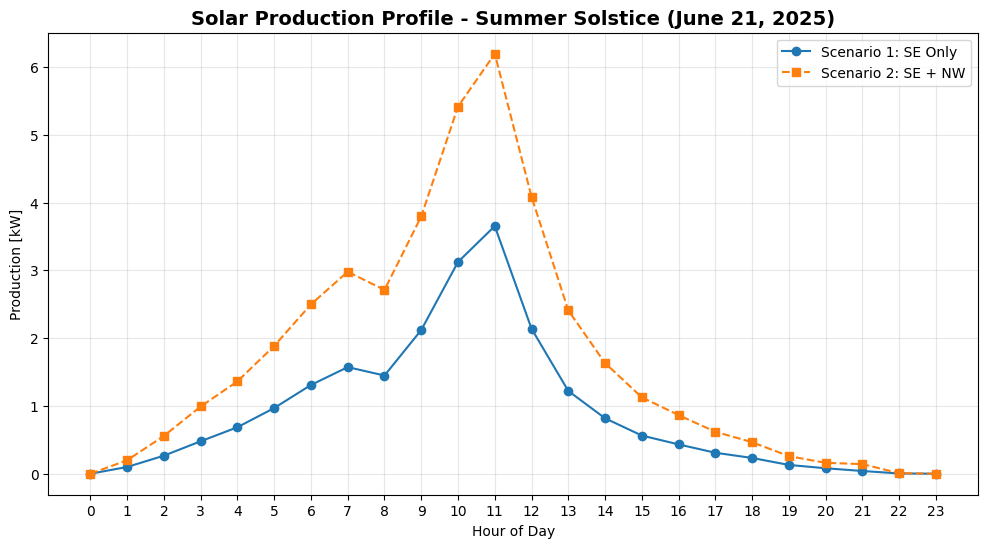

In [5]:
# Find June 21st start index
day_start = (time_index.month == 6) & (time_index.day == 21)
indices = np.where(day_start)[0]
start_idx = indices[0]
end_idx = start_idx + 24

plt.figure(figsize=(12, 6))
plt.plot(range(24), ts1['p_solar'].iloc[start_idx:end_idx], label="Scenario 1: SE Only", marker='o')
plt.plot(range(24), ts2['p_solar'].iloc[start_idx:end_idx], label="Scenario 2: SE + NW", linestyle="--", marker='s')
plt.title("Solar Production Profile - Summer Solstice (June 21, 2025)", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Production [kW]")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 3c. Summary Metrics
Comparing the overall performance and cost impact.

In [6]:
summary = pd.DataFrame({
    "Metric": [
        "Total Annual Production [kWh]", 
        "Specific Yield [kWh/kWp]", 
        "Peak Power Reached [kW]", 
        "Net Energy Cost [SEK]",
        "Savings vs Baseline [SEK]"
    ],
    "Scenario 1 (SE Only)": [
        ts1['p_solar'].sum(),
        ts1['p_solar'].sum() / 10.0,
        ts1['p_solar'].max(),
        metrics1['net_electricity_cost_sek'],
        8709.94 - metrics1['net_electricity_cost_sek'] # Baseline cost from Walkthrough
    ],
    "Scenario 2 (SE + NW)": [
        ts2['p_solar'].sum(),
        ts2['p_solar'].sum() / 20.0,
        ts2['p_solar'].max(),
        metrics2['net_electricity_cost_sek'],
        8709.94 - metrics2['net_electricity_cost_sek']
    ]
})

summary.style.format(precision=1, thousands=",")

,Metric,Scenario 1 (SE Only),Scenario 2 (SE + NW)
0,Total Annual Production [kWh],"8,920.1","13,404.4"
1,Specific Yield [kWh/kWp],892.0,670.2
2,Peak Power Reached [kW],7.8,9.9
3,Net Energy Cost [SEK],"1,818.2",-617.3
4,Savings vs Baseline [SEK],"6,891.8","9,327.3"
